------------------
 ## Suicide Sentiment Analysis Project 
 - Using TF-IDF As Feature Extraction
 - Using Some Classification models As RandomForest, LinearSVC
 - Using Some Preprocessing as Lemmatization, Removing Stop Words
 - Finally,  The best Results in this notebook is 93%.
----------------

In [6]:
import pandas as pd
import numpy as np 
from tabulate import tabulate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn import metrics
import nltk
import re
import string
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn import metrics
nltk.download('vader_lexicon')
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/sfodor/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## Read Suicide_Detection File

In [11]:
Suicide = pd.read_csv('input/suicide-watch/Suicide_Detection.csv')
Suicide = Suicide.iloc[: len(Suicide) // 3].copy()
Suicide = Suicide.drop(columns=['Unnamed: 0'], errors='ignore')

## Preparing For Stopword removal and lemmatization

In [12]:
nltk.download('stopwords')
stopwords = nltk.corpus.stopwords.words('english')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /home/sfodor/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
X = Suicide.drop('class', axis=1)
y = Suicide['class']


# Text Pre Proceessing

In [15]:
# To remove emails
email_regex = r'([a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+)'
regexes_to_remove = [email_regex, r'Subject:', r'Re:']

for i in range(0, len(X)):
    # removing all special charachter
    review = re.sub('[^a-zA-Z]', ' ', str(X['text'][i]))
    # make document as lowerCase
    review = review.lower()
    # splitting the documents into words for ex ['iam', 'omar']
    review = review.split()
    # make limmatization --> (change, changing, changes)---> (change)
    review = [lemmatizer.lemmatize(word) for word in review if not word in set(stopwords)]
    # join the document agian
    review = ' '.join(review)
    
    # removing mails
    for r in regexes_to_remove:
        X['text'][i] = re.sub(r, '', review)


## Data Splitting 

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

## Feature extraction

- ### TF-IDF

In [17]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
tfidf_vectorizer_n12 = TfidfVectorizer(max_features=10000, ngram_range=(1,2))


X_tfidf_train = tfidf_vectorizer.fit_transform(X_train['text'])
X_tfidf_test = tfidf_vectorizer.transform(X_test['text'])

X_tfidf_train_n12= tfidf_vectorizer_n12.fit_transform(X_train['text'])
X_tfidf_test_n12=tfidf_vectorizer_n12.transform(X_test['text'])

 - ### Bag of wards 

In [18]:
vectorizer = CountVectorizer()
  
X_bow_train = vectorizer.fit_transform(X_train['text'])
X_bow_test = vectorizer.transform(X_test['text'])


- ### VADER


In [19]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer as SIA
def get_vader_scores(data):
    sid=SIA()
    vader_df=data.copy()
    vader_df['scores'] = vader_df['text'].apply(lambda txt: sid.polarity_scores(str(txt)))
    
    vader_df['neg_score'] = vader_df['scores'].apply(lambda txt: txt['neg'])
    vader_df['neu_score'] =vader_df['scores'].apply(lambda txt: txt['neu'])
    vader_df['pos_score'] = vader_df['scores'].apply(lambda txt: txt['pos'])
    vader_df['compound'] = vader_df['scores'].apply(lambda txt: txt['compound'])
    vader_df.drop('scores', axis=1, inplace=True)
    vader_df.drop('text', axis=1, inplace=True)
    return vader_df


In [ ]:
X_vader_train = get_vader_scores(X_train)
X_vader_test= get_vader_scores(X_test)
X_vader_train

## Feature Selection

In [21]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

# We Can select any model but linearSVC has l1 norm penality which deals with sparse
lsvc = LinearSVC(C=100, penalty='l1', max_iter=500, dual=False)
lsvc.fit(X_tfidf_train, y_train)

# This function select the best features that has high weigh
fs = SelectFromModel(lsvc, prefit=True)
# This function redeuce X to the selected features
X_selection = fs.transform(X_tfidf_train)
X_test_selection = fs.transform(X_tfidf_test)


lsvc.fit(X_tfidf_train_n12, y_train)
fs_n12 = SelectFromModel(lsvc, prefit=True)
X_selection_n12 = fs_n12.transform(X_tfidf_train_n12)
X_test_selection_n12 = fs_n12.transform(X_tfidf_test_n12)

lsvc.fit(X_bow_train, y_train)
fs_n12 = SelectFromModel(lsvc, prefit=True)
X_selection_bow = fs_n12.transform(X_bow_train)
X_test_selection_bow = fs_n12.transform(X_bow_test)


### plotting results function 

In [24]:
import matplotlib.pyplot as plt
def plot_results(data):
    
    barWidth = 0.15
    # set heights of bars

    bars1 = [data[0][1],data[1][1], data[2][1]]
    bars2 = [data[0][2], data[1][2], data[2][2]]
    bars3 = [data[0][3], data[1][3], data[2][3]]
    bars4 = [data[0][4], data[1][4], data[2][4]]
    

    # Set position of bar on X axis
    r1 = np.arange(len(bars1))
    r2 = [x + barWidth for x in r1]
    r3 = [x + barWidth for x in r2]
    r4 = [x + barWidth for x in r3]
    

    # Make the plot
    plt.bar(r1, bars1, color='r', width=barWidth, edgecolor='white', label='tfidf')
    plt.bar(r2, bars2, color='b', width=barWidth, edgecolor='white', label='tfidf_n12')
    plt.bar(r3, bars3, color='#2d7f5e', width=barWidth, edgecolor='white', label='bow')
    plt.bar(r4, bars4, color='#9a7f5e', width=barWidth, edgecolor='white', label='vader')
    

    # Add xticks on the middle of the group bars
    plt.xlabel('group', fontweight='bold')
    plt.xticks([r + barWidth for r in range(len(bars1))], ['precision', 'recall', 'f1-score'])

    # Create legend & Show graphic
    plt.legend()
    plt.grid()
    plt.show()

##  Using LinearSVC

In [25]:
lsvc = LinearSVC(C=1000, penalty='l1', max_iter=500, dual=False)
lsvc.fit(X_selection, y_train)
y_predict_tfidf = lsvc.predict(X_test_selection)

lsvc.fit(X_selection_n12,y_train)
y_predict_tfidf_n12 = lsvc.predict(X_test_selection_n12)

lsvc.fit(X_selection_bow,y_train)
y_predict_bow = lsvc.predict(X_test_selection_bow)

lsvc.fit(X_vader_train,y_train)
y_predict_vader = lsvc.predict(X_vader_test)

linear_svm_tfidf_results=metrics.precision_recall_fscore_support(y_test, y_predict_tfidf)
linear_svm_tfidf_n12_results=metrics.precision_recall_fscore_support(y_test, y_predict_tfidf_n12)
linear_svm_bow_results=metrics.precision_recall_fscore_support(y_test, y_predict_bow)
vader_svm_results=metrics.precision_recall_fscore_support(y_test, y_predict_vader)

In [15]:
tfidf_acc= metrics.accuracy_score(y_test, y_predict_tfidf)
tfidf_n12_acc=accuracy_score(y_test, y_predict_tfidf_n12)
bow_acc= accuracy_score(y_test, y_predict_bow)
vader_acc=accuracy_score(y_test, y_predict_vader)

In [16]:
data1 = [['TF-IDF','TF-IDF 2-grams ','bag of words','vader'],
         ['precision',linear_svm_tfidf_results[0][0],linear_svm_tfidf_n12_results[0][0],linear_svm_bow_results[0][0],
          vader_svm_results[0][0]],
         ['recall',linear_svm_tfidf_results[1][0],linear_svm_tfidf_n12_results[1][0],linear_svm_bow_results[1][0],
          vader_svm_results[1][0]],
         ['F1-score',linear_svm_tfidf_results[2][0],linear_svm_tfidf_n12_results[2][0],linear_svm_bow_results[2][0],
          vader_svm_results[2][0]],
        ['accuracy',tfidf_acc,tfidf_n12_acc,bow_acc,
          vader_acc]]

In [17]:
print(tabulate(data1,headers='firstrow',tablefmt='fancy_grid'))

╒═══════════╤══════════╤═══════════════════╤════════════════╤══════════╕
│           │   TF-IDF │   TF-IDF 2-grams  │   bag of words │    vader │
╞═══════════╪══════════╪═══════════════════╪════════════════╪══════════╡
│ precision │ 0.866338 │          0.863772 │       0.862199 │ 0.693714 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ recall    │ 0.858539 │          0.840964 │       0.879201 │ 0.696331 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ F1-score  │ 0.862421 │          0.852215 │       0.870617 │ 0.69502  │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ accuracy  │ 0.862332 │          0.853413 │       0.868666 │ 0.692865 │
╘═══════════╧══════════╧═══════════════════╧════════════════╧══════════╛


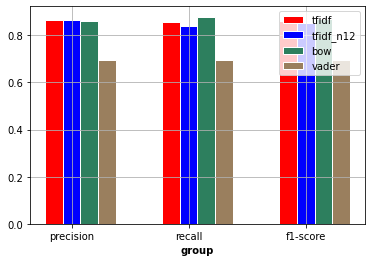

In [18]:
plot_results(data1[1:])

## Using RandomForest

In [19]:
clf = RandomForestClassifier(max_depth=10)
clf.fit(X_selection, y_train)
y_predict_tfidf_2 = clf.predict(X_test_selection)

clf.fit(X_selection_n12, y_train)
y_predict_tfidf_n12_2 = clf.predict(X_test_selection_n12)

clf.fit(X_selection_bow, y_train)
y_predict_bow_2 = clf.predict(X_test_selection_bow)

clf.fit(X_vader_train, y_train)
y_predict_vader_2 = clf.predict(X_vader_test)

In [20]:
RandomForest_tfidf_results=metrics.precision_recall_fscore_support(y_test, y_predict_tfidf_2)
RandomForest_tfidf_n12_results=metrics.precision_recall_fscore_support(y_test, y_predict_tfidf_n12_2)
RandomForest_bow_results=metrics.precision_recall_fscore_support(y_test, y_predict_bow_2)
RandomForest_vader_results=metrics.precision_recall_fscore_support(y_test, y_predict_vader_2)

In [21]:
RandomForest_tfidf_acc= metrics.accuracy_score(y_test, y_predict_tfidf_2)
RandomForest_tfidf_n12_acc=accuracy_score(y_test, y_predict_tfidf_n12_2)
RandomForest_bow_acc= accuracy_score(y_test, y_predict_bow_2)
RandomForest_vader_acc=accuracy_score(y_test, y_predict_vader_2)

In [22]:
data2 = [['TF-IDF','TF-IDF 2-grams ','bag of words','vader'],
         ['precision',RandomForest_tfidf_results[0][0],RandomForest_tfidf_n12_results[0][0],RandomForest_bow_results[0][0],
          RandomForest_vader_results[0][0]],
         ['recall',RandomForest_tfidf_results[1][0],RandomForest_tfidf_n12_results[1][0],RandomForest_bow_results[1][0],
          RandomForest_vader_results[1][0]],
         ['F1-score',RandomForest_tfidf_results[2][0],RandomForest_tfidf_n12_results[2][0],RandomForest_bow_results[2][0],
          RandomForest_vader_results[2][0]],
        ['accuracy',RandomForest_tfidf_acc,RandomForest_tfidf_n12_acc, RandomForest_bow_acc,
          RandomForest_vader_acc]]

In [23]:
print(tabulate(data2,headers='firstrow',tablefmt='fancy_grid'))

╒═══════════╤══════════╤═══════════════════╤════════════════╤══════════╕
│           │   TF-IDF │   TF-IDF 2-grams  │   bag of words │    vader │
╞═══════════╪══════════╪═══════════════════╪════════════════╪══════════╡
│ precision │ 0.793173 │          0.791629 │       0.778385 │ 0.78394  │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ recall    │ 0.908436 │          0.911351 │       0.903978 │ 0.776749 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ F1-score  │ 0.846901 │          0.847282 │       0.836493 │ 0.780328 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ accuracy  │ 0.834928 │          0.834885 │       0.822389 │ 0.780205 │
╘═══════════╧══════════╧═══════════════════╧════════════════╧══════════╛


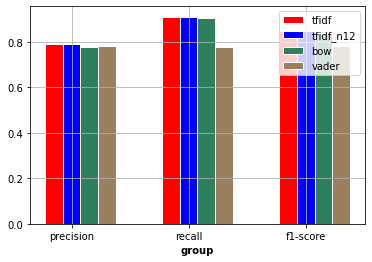

In [24]:
plot_results(data2[1:])

## Using Ensemble Learning 

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression,  SGDClassifier
from sklearn.svm import SVC

In [26]:
log_clf = LogisticRegression(solver="lbfgs")
rnd_clf = RandomForestClassifier(n_estimators=100)
svm_clf = SVC(gamma="scale", probability=True)
sgd = SGDClassifier(alpha=.0001, max_iter=50, loss='log',
                                       penalty="elasticnet", n_jobs=-1)

voting_clf = VotingClassifier(
estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
voting='soft')



In [27]:
voting_clf.fit(X_selection, y_train)
y_predict_tfidf_4 = voting_clf.predict(X_test_selection)

voting_clf.fit(X_selection_n12, y_train)
y_predict_tfidf_n12_4 = voting_clf.predict(X_test_selection_n12)

voting_clf.fit(X_selection_bow, y_train)
y_predict_bow_4 = voting_clf.predict(X_test_selection_bow)

voting_clf.fit(X_vader_train, y_train)
y_predict_vader_4 = voting_clf.predict(X_vader_test)

In [28]:
en_tfidf_results=metrics.precision_recall_fscore_support(y_test, y_predict_tfidf_4)
en_tfidf_n12_results=metrics.precision_recall_fscore_support(y_test, y_predict_tfidf_n12_4)
en_bow_results=metrics.precision_recall_fscore_support(y_test, y_predict_bow_4)
en_vader_results=metrics.precision_recall_fscore_support(y_test, y_predict_vader_4)

In [29]:
en_tfidf_acc= metrics.accuracy_score(y_test, y_predict_tfidf_4)
en_tfidf_n12_acc=accuracy_score(y_test, y_predict_tfidf_n12_4)
en_bow_acc= accuracy_score(y_test, y_predict_bow_4)
en_vader_acc=accuracy_score(y_test, y_predict_vader_4)

In [30]:
data3= [['TF-IDF','TF-IDF 2-grams ','bag of words','vader'],
        ['precision',en_tfidf_results[0][0],en_tfidf_n12_results[0][0],en_bow_results[0][0],
          en_vader_results[0][0]],
         ['recall',en_tfidf_results[1][0],en_tfidf_n12_results[1][0],en_bow_results[1][0],
          en_vader_results[1][0]],
         ['F1-score',en_tfidf_results[2][0],en_tfidf_n12_results[2][0],en_bow_results[2][0],
          en_vader_results[2][0]],
       ['accuracy',en_tfidf_acc,en_tfidf_n12_acc, en_bow_acc,
          en_vader_acc]]

In [31]:
print(tabulate(data3,headers='firstrow',tablefmt='fancy_grid'))

╒═══════════╤══════════╤═══════════════════╤════════════════╤══════════╕
│           │   TF-IDF │   TF-IDF 2-grams  │   bag of words │    vader │
╞═══════════╪══════════╪═══════════════════╪════════════════╪══════════╡
│ precision │ 0.924796 │          0.925695 │       0.909421 │ 0.770631 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ recall    │ 0.940415 │          0.939901 │       0.943416 │ 0.780607 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ F1-score  │ 0.93254  │          0.932743 │       0.926107 │ 0.775587 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ accuracy  │ 0.931618 │          0.931877 │       0.924336 │ 0.772966 │
╘═══════════╧══════════╧═══════════════════╧════════════════╧══════════╛


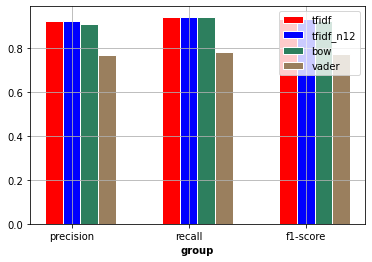

In [32]:
plot_results(data3[1:])

## Using Bagging Method

In [33]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
bag_clf = BaggingClassifier(
DecisionTreeClassifier(), n_estimators=500,
max_samples=100, bootstrap=True, n_jobs=-1)

bag_clf.fit(X_selection, y_train)
y_pred_5 = bag_clf.predict(X_test_selection)

bag_clf.fit(X_selection_n12, y_train)
y_pred_n12_5 = bag_clf.predict(X_test_selection_n12)

bag_clf.fit(X_selection_bow, y_train)
y_pred_bow_5 = bag_clf.predict(X_test_selection_bow)

bag_clf.fit(X_vader_train, y_train)
y_pred_vader_5 = bag_clf.predict(X_vader_test)

In [34]:
bag_tfidf_results=metrics.precision_recall_fscore_support(y_test, y_pred_5)
bag_tfidf_n12_results=metrics.precision_recall_fscore_support(y_test, y_pred_n12_5)
bag_bow_results=metrics.precision_recall_fscore_support(y_test, y_pred_bow_5)
bag_vader_results=metrics.precision_recall_fscore_support(y_test, y_pred_vader_5)

In [35]:
bag_tfidf_acc= metrics.accuracy_score(y_test, y_pred_5)
bag_tfidf_n12_acc=accuracy_score(y_test, y_pred_n12_5)
bag_bow_acc= accuracy_score(y_test, y_pred_bow_5)
bag_vader_acc=accuracy_score(y_test, y_pred_vader_5)

In [36]:
data4= [['TF-IDF','TF-IDF 2-grams ','bag of words','vader'],
        ['precision',bag_tfidf_results[0][0],bag_tfidf_n12_results[0][0],bag_bow_results[0][0],
          bag_vader_results[0][0]],
         ['recall',bag_tfidf_results[1][0],bag_tfidf_n12_results[1][0],bag_bow_results[1][0],
          bag_vader_results[1][0]],
         ['F1-score',bag_tfidf_results[2][0],bag_tfidf_n12_results[2][0],bag_bow_results[2][0],
          bag_vader_results[2][0]],
        ['accuracy',bag_tfidf_acc,bag_tfidf_n12_acc, bag_bow_acc,
          bag_vader_acc]]

In [37]:
print(tabulate(data4,headers='firstrow',tablefmt='fancy_grid'))

╒═══════════╤══════════╤═══════════════════╤════════════════╤══════════╕
│           │   TF-IDF │   TF-IDF 2-grams  │   bag of words │    vader │
╞═══════════╪══════════╪═══════════════════╪════════════════╪══════════╡
│ precision │ 0.799801 │          0.800015 │       0.805179 │ 0.780667 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ recall    │ 0.894633 │          0.887603 │       0.876972 │ 0.767147 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ F1-score  │ 0.844563 │          0.841536 │       0.839544 │ 0.773848 │
├───────────┼──────────┼───────────────────┼────────────────┼──────────┤
│ accuracy  │ 0.834497 │          0.831998 │       0.831524 │ 0.774647 │
╘═══════════╧══════════╧═══════════════════╧════════════════╧══════════╛


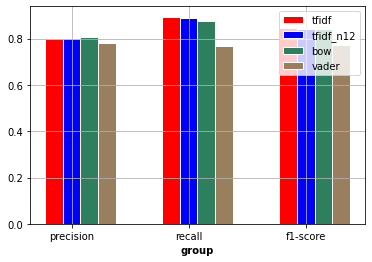

In [38]:
plot_results(data4[1:])